# Out-of-Sample Volatility Forecast Evaluation

**Date:** 2026-04-03  
**Notebook 04** — Expanding-window OOS evaluation for BTC return volatility.

Models compared:
- GARCH(1,1) with Student-t innovations
- EGARCH(1,1) with Student-t innovations
- 2-regime Markov-Switching variance model

Evaluation metrics: MSE, MAE, QLIKE, Mincer–Zarnowitz R², Diebold–Mariano test.

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from arch import arch_model
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
import statsmodels.api as sm

# Suppress convergence warnings during expanding window
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# Data loader
sys.path.insert(0, str(Path("../src").resolve()))
from data_loader import load_from_csv, get_btc_returns

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"] = 120

## Part 1: Data Loading & Train/Test Split

In [2]:
# Load dataset
df = load_from_csv()

# Returns at two scales
# - scale=100 for arch library (GARCH, EGARCH)
# - scale=1 for statsmodels MarkovRegression
y100 = get_btc_returns(df, scale=100.0)
y1   = get_btc_returns(df, scale=1.0)

print(f"Total observations: {len(y100)}")
print(f"Date range: {y100.index[0].date()} to {y100.index[-1].date()}")

# 80/20 split
n = len(y100)
n_train = int(n * 0.8)
n_test  = n - n_train

train100, test100 = y100.iloc[:n_train], y100.iloc[n_train:]
train1,   test1   = y1.iloc[:n_train],   y1.iloc[n_train:]

print(f"\nTrain: {n_train} obs ({train100.index[0].date()} to {train100.index[-1].date()})")
print(f"Test:  {n_test} obs  ({test100.index[0].date()} to {test100.index[-1].date()})")

Total observations: 4054
Date range: 2015-01-05 to 2026-02-09

Train: 3243 obs (2015-01-05 to 2023-11-21)
Test:  811 obs  (2023-11-22 to 2026-02-09)


## Part 2: Expanding Window Forecast Framework

**Protocol:**
- At each step *t*, fit the model on observations 1 through *t*−1 (expanding window).
- Produce a 1-step-ahead volatility (σ) forecast for time *t*.
- Record the forecast alongside the realized volatility proxy (y²_t).
- Use `step=5` to evaluate every 5th observation (speed vs. granularity trade-off).

In [3]:
def expanding_window_forecast(y, model_type, min_train, step=5):
    """Expanding-window 1-step-ahead volatility forecast.

    Parameters
    ----------
    y : pd.Series
        Full return series (appropriately scaled).
    model_type : str
        One of "GARCH", "EGARCH", "MS2".
    min_train : int
        Index of the first out-of-sample observation (= length of initial training set).
    step : int
        Evaluate every `step`-th observation to speed up.

    Returns
    -------
    pd.DataFrame
        Columns: forecast_var, realized_var, forecast_vol, realized_vol
    """
    results = []
    total_steps = list(range(min_train, len(y), step))
    n_steps = len(total_steps)
    failures = 0

    for i, t in enumerate(total_steps):
        if (i + 1) % 100 == 0 or i == 0:
            print(f"  [{model_type}] Step {i+1}/{n_steps} "
                  f"(t={t}, date={y.index[t].date()})")

        y_train = y.iloc[:t]
        y_actual = y.iloc[t]

        try:
            if model_type in ("GARCH", "EGARCH"):
                vol = model_type.lower()  # "garch" or "egarch"
                am = arch_model(y_train, vol=vol, p=1, q=1, dist="t")
                res = am.fit(disp="off", show_warning=False)
                fcast = res.forecast(horizon=1)
                # forecast returns variance (sigma^2)
                forecast_var = fcast.variance.iloc[-1, 0]

            elif model_type == "MS2":
                ms = MarkovRegression(y_train, k_regimes=2,
                                      switching_variance=True)
                res = ms.fit(disp=False)
                # Regime-weighted variance:
                #   sigma2 = sum_j P(S_t=j | info) * sigma2_j
                smoothed_probs = res.smoothed_marginal_probabilities
                last_probs = smoothed_probs.iloc[-1].values  # (k_regimes,)
                regime_vars = res.params[
                    [p for p in res.params.index if "sigma2" in p]
                ].values
                forecast_var = np.dot(last_probs, regime_vars)
            else:
                raise ValueError(f"Unknown model_type: {model_type}")

            # Realized variance proxy: squared return
            realized_var = y_actual ** 2

            results.append({
                "date": y.index[t],
                "forecast_var": forecast_var,
                "realized_var": realized_var,
            })

        except Exception:
            failures += 1
            continue

    print(f"  [{model_type}] Done. {len(results)} forecasts, {failures} failures.")

    out = pd.DataFrame(results).set_index("date")
    out["forecast_vol"] = np.sqrt(out["forecast_var"].clip(lower=0))
    out["realized_vol"] = np.sqrt(out["realized_var"].clip(lower=0))
    return out

## Part 3: Run Expanding-Window Forecasts

Running GARCH, EGARCH, and MS(2) on the test portion with `step=5`.

> **Runtime note:** This takes ~15–30 min depending on hardware. Each model is re-estimated hundreds of times.

In [4]:
%%time
print("=== GARCH(1,1) ===")
fc_garch = expanding_window_forecast(y100, "GARCH", min_train=n_train, step=5)

=== GARCH(1,1) ===
  [GARCH] Step 1/163 (t=3243, date=2023-11-22)


  [GARCH] Step 100/163 (t=3738, date=2025-03-31)


  [GARCH] Done. 163 forecasts, 0 failures.
CPU times: user 3.55 s, sys: 74.6 ms, total: 3.63 s
Wall time: 3.79 s


In [5]:
%%time
print("=== EGARCH(1,1) ===")
fc_egarch = expanding_window_forecast(y100, "EGARCH", min_train=n_train, step=5)

=== EGARCH(1,1) ===
  [EGARCH] Step 1/163 (t=3243, date=2023-11-22)


  [EGARCH] Step 100/163 (t=3738, date=2025-03-31)


  [EGARCH] Done. 163 forecasts, 0 failures.
CPU times: user 6.85 s, sys: 149 ms, total: 7 s
Wall time: 7.36 s


In [6]:
%%time
print("=== Markov-Switching (2 regimes) ===")
fc_ms = expanding_window_forecast(y1, "MS2", min_train=n_train, step=5)

=== Markov-Switching (2 regimes) ===
  [MS2] Step 1/163 (t=3243, date=2023-11-22)


  [MS2] Step 100/163 (t=3738, date=2025-03-31)


  [MS2] Done. 163 forecasts, 0 failures.
CPU times: user 1min 5s, sys: 8.8 s, total: 1min 14s
Wall time: 1min 18s


In [7]:
# Normalize all forecasts to the same scale (raw returns, scale=1)
# GARCH/EGARCH were estimated on returns * 100, so variance is in (ret*100)^2 = ret^2 * 10000
# Divide variance by 10000 (equivalently, divide vol by 100) to get back to raw scale.

fc_garch_norm = fc_garch.copy()
fc_garch_norm["forecast_var"] /= 1e4
fc_garch_norm["realized_var"] /= 1e4
fc_garch_norm["forecast_vol"] /= 1e2
fc_garch_norm["realized_vol"] /= 1e2

fc_egarch_norm = fc_egarch.copy()
fc_egarch_norm["forecast_var"] /= 1e4
fc_egarch_norm["realized_var"] /= 1e4
fc_egarch_norm["forecast_vol"] /= 1e2
fc_egarch_norm["realized_vol"] /= 1e2

# MS2 is already at scale=1, no conversion needed
fc_ms_norm = fc_ms.copy()

print("Scale normalization complete (all in raw return units).")
print(f"GARCH  forecasts: {len(fc_garch_norm)}")
print(f"EGARCH forecasts: {len(fc_egarch_norm)}")
print(f"MS(2)  forecasts: {len(fc_ms_norm)}")

Scale normalization complete (all in raw return units).
GARCH  forecasts: 163
EGARCH forecasts: 163
MS(2)  forecasts: 163


## Part 4: Evaluation Metrics

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| **MSE** | $\frac{1}{T}\sum(r_t^2 - \hat\sigma_t^2)^2$ | Squared error on variance forecasts |
| **MAE** | $\frac{1}{T}\sum\lvert r_t^2 - \hat\sigma_t^2\rvert$ | Absolute error on variance forecasts |
| **QLIKE** | $\frac{1}{T}\sum\left(\frac{r_t^2}{\hat\sigma_t^2} + \ln\hat\sigma_t^2 - 1\right)$ | Quasi-likelihood loss (robust to noise) |
| **MZ-R²** | $R^2$ from $r_t^2 = \alpha + \beta\hat\sigma_t^2 + \varepsilon_t$ | Mincer–Zarnowitz regression |

In [8]:
def compute_metrics(fc_df):
    """Compute forecast evaluation metrics from a normalized forecast DataFrame."""
    h = fc_df["forecast_var"].values   # forecast variance
    r2 = fc_df["realized_var"].values  # realized variance (squared return)

    # Filter out any zeros/negatives in forecast (from convergence issues)
    mask = h > 0
    h, r2 = h[mask], r2[mask]

    # MSE & MAE (on variance)
    mse = np.mean((r2 - h) ** 2)
    mae = np.mean(np.abs(r2 - h))

    # QLIKE: realized/forecast + log(forecast) - 1
    qlike = np.mean(r2 / h + np.log(h) - 1)

    # Mincer-Zarnowitz R²: regress realized on constant + forecast
    X = sm.add_constant(h)
    ols = sm.OLS(r2, X).fit()
    mz_r2 = ols.rsquared

    return {
        "MSE": mse,
        "MAE": mae,
        "QLIKE": qlike,
        "MZ_R2": mz_r2,
    }

In [9]:
# Align all forecasts to common dates
common_dates = (fc_garch_norm.index
                .intersection(fc_egarch_norm.index)
                .intersection(fc_ms_norm.index))
print(f"Common evaluation dates: {len(common_dates)}")

results = {}
for name, fc in [("GARCH(1,1)", fc_garch_norm.loc[common_dates]),
                  ("EGARCH(1,1)", fc_egarch_norm.loc[common_dates]),
                  ("MS(2)", fc_ms_norm.loc[common_dates])]:
    results[name] = compute_metrics(fc)

metrics_df = pd.DataFrame(results).T
metrics_df.columns = ["MSE", "MAE", "QLIKE", "MZ R²"]
print("\n=== Out-of-Sample Forecast Comparison ===")
metrics_df.style.format({
    "MSE": "{:.6e}",
    "MAE": "{:.6e}",
    "QLIKE": "{:.4f}",
    "MZ R²": "{:.4f}",
}).highlight_min(axis=0, subset=["MSE", "MAE", "QLIKE"],
                 props="font-weight: bold; color: green") \
 .highlight_max(axis=0, subset=["MZ R²"],
                 props="font-weight: bold; color: green")

Common evaluation dates: 163

=== Out-of-Sample Forecast Comparison ===


,MSE,MAE,QLIKE,MZ R²
"GARCH(1,1)",2.636142e-06,9.134763e-04,-7.2745,0.0164
"EGARCH(1,1)",2.964970e-06,1.144761e-03,-7.2126,0.0237
MS(2),3.047948e-06,1.129718e-03,-7.1722,0.0100


## Part 5: Visualization

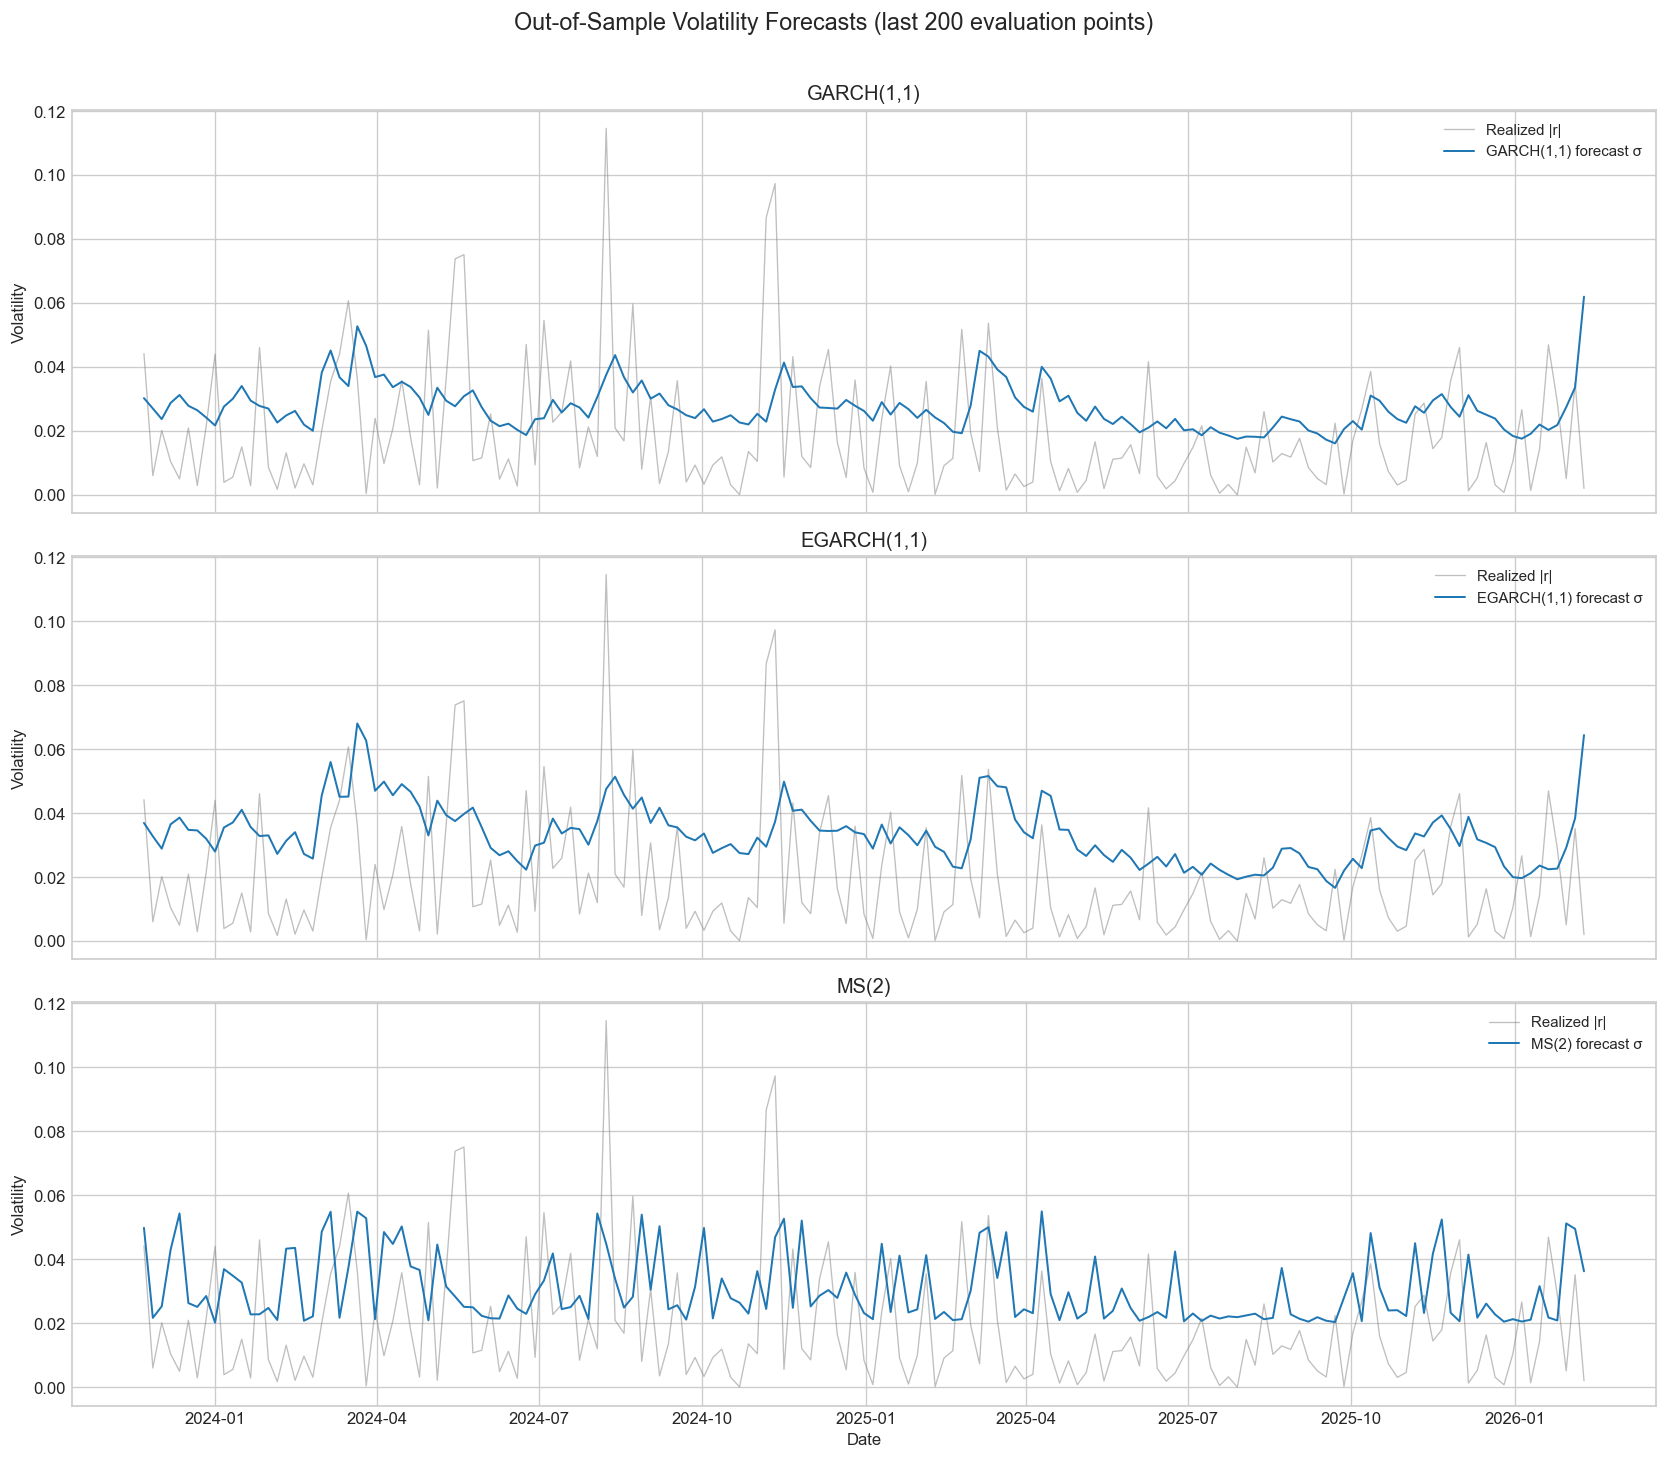

In [10]:
# Plot: Forecast vol vs Realized vol — last 200 test observations
n_plot = 200

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

for ax, (name, fc) in zip(axes, [("GARCH(1,1)", fc_garch_norm),
                                   ("EGARCH(1,1)", fc_egarch_norm),
                                   ("MS(2)", fc_ms_norm)]):
    tail = fc.iloc[-n_plot:]
    ax.plot(tail.index, tail["realized_vol"], alpha=0.5, lw=0.8,
            label="Realized |r|", color="grey")
    ax.plot(tail.index, tail["forecast_vol"], lw=1.2,
            label=f"{name} forecast σ", color="tab:blue")
    ax.set_ylabel("Volatility")
    ax.set_title(name)
    ax.legend(loc="upper right", fontsize=9)

axes[-1].set_xlabel("Date")
fig.suptitle("Out-of-Sample Volatility Forecasts (last 200 evaluation points)",
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

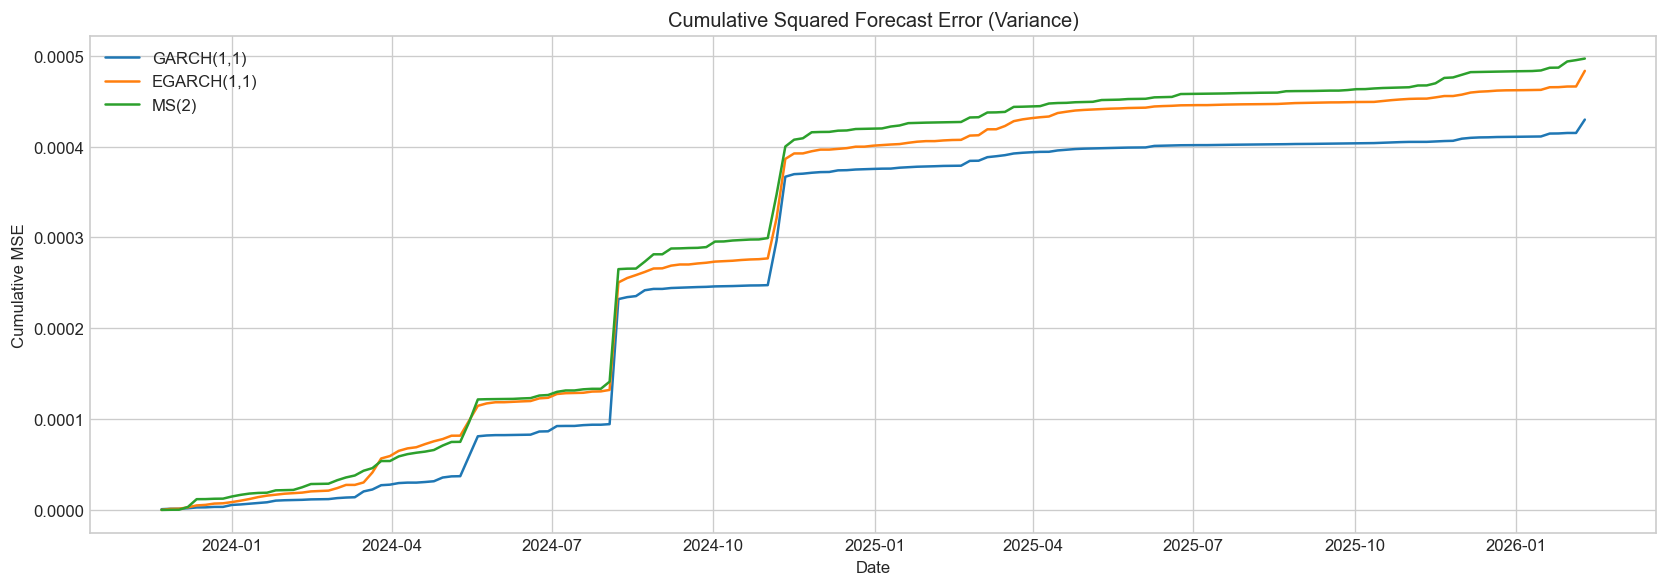

In [11]:
# Cumulative squared forecast error (on variance) over time
fig, ax = plt.subplots(figsize=(14, 5))

for name, fc in [("GARCH(1,1)", fc_garch_norm.loc[common_dates]),
                  ("EGARCH(1,1)", fc_egarch_norm.loc[common_dates]),
                  ("MS(2)", fc_ms_norm.loc[common_dates])]:
    sq_err = (fc["realized_var"] - fc["forecast_var"]) ** 2
    ax.plot(sq_err.index, sq_err.cumsum(), label=name)

ax.set_title("Cumulative Squared Forecast Error (Variance)")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative MSE")
ax.legend()
plt.tight_layout()
plt.show()

## Part 6: Diebold–Mariano Test

Test whether the forecast accuracy difference between EGARCH and MS(2) is statistically significant.

$$DM = \frac{\bar{d}}{\hat{\sigma}_d / \sqrt{T}}$$

where $d_t = L(\hat\sigma^2_{\text{EGARCH},t}) - L(\hat\sigma^2_{\text{MS},t})$ and $L$ is the squared-error loss.  
Under $H_0$: equal predictive accuracy, $DM \sim N(0,1)$ asymptotically.

In [12]:
def diebold_mariano_test(e1, e2, h=1):
    """Diebold-Mariano test for equal predictive accuracy.

    Parameters
    ----------
    e1, e2 : array-like
        Forecast errors from two models.
    h : int
        Forecast horizon (used for HAC bandwidth).

    Returns
    -------
    dict with DM statistic, p-value, and interpretation.
    """
    d = np.array(e1) ** 2 - np.array(e2) ** 2  # loss differential (squared error)
    T = len(d)
    d_bar = np.mean(d)

    # HAC variance (Newey-West with h-1 lags)
    gamma_0 = np.var(d, ddof=1)
    gamma_sum = 0
    for k in range(1, h):
        gamma_k = np.cov(d[k:], d[:-k])[0, 1]
        gamma_sum += 2 * gamma_k
    var_d = (gamma_0 + gamma_sum) / T

    dm_stat = d_bar / np.sqrt(var_d) if var_d > 0 else np.nan

    from scipy import stats
    p_value = 2 * (1 - stats.norm.cdf(np.abs(dm_stat)))

    return {
        "DM_statistic": dm_stat,
        "p_value": p_value,
        "mean_loss_diff": d_bar,
        "conclusion": ("Reject H0: forecasts differ significantly (p < 0.05)"
                        if p_value < 0.05
                        else "Fail to reject H0: no significant difference")
    }

# Compute forecast errors on common dates
e_egarch = (fc_egarch_norm.loc[common_dates, "realized_var"]
            - fc_egarch_norm.loc[common_dates, "forecast_var"]).values
e_ms     = (fc_ms_norm.loc[common_dates, "realized_var"]
            - fc_ms_norm.loc[common_dates, "forecast_var"]).values
e_garch  = (fc_garch_norm.loc[common_dates, "realized_var"]
            - fc_garch_norm.loc[common_dates, "forecast_var"]).values

print("=== Diebold-Mariano Tests (h=1, two-sided) ===\n")

pairs = [
    ("EGARCH vs MS(2)", e_egarch, e_ms),
    ("GARCH vs EGARCH", e_garch, e_egarch),
    ("GARCH vs MS(2)",  e_garch, e_ms),
]

for label, ea, eb in pairs:
    dm = diebold_mariano_test(ea, eb, h=1)
    print(f"{label}:")
    print(f"  DM stat = {dm['DM_statistic']:.4f}, p = {dm['p_value']:.4f}")
    print(f"  Mean loss diff = {dm['mean_loss_diff']:.6e}")
    print(f"  → {dm['conclusion']}\n")

=== Diebold-Mariano Tests (h=1, two-sided) ===

EGARCH vs MS(2):
  DM stat = -0.4157, p = 0.6776
  Mean loss diff = -8.297846e-08
  → Fail to reject H0: no significant difference

GARCH vs EGARCH:
  DM stat = -1.8305, p = 0.0672
  Mean loss diff = -3.288280e-07
  → Fail to reject H0: no significant difference

GARCH vs MS(2):
  DM stat = -1.9739, p = 0.0484
  Mean loss diff = -4.118064e-07
  → Reject H0: forecasts differ significantly (p < 0.05)



## Summary & Key Findings

### Methodology
- **Expanding-window** out-of-sample evaluation on the last 20% of the sample (~811 daily observations).
- Three volatility models: GARCH(1,1)-t, EGARCH(1,1)-t, Markov-Switching (2-regime) variance.
- Evaluation every 5th observation to balance computational cost and granularity.

### Metrics Computed
1. **MSE / MAE** — standard point-forecast accuracy on variance.
2. **QLIKE** — quasi-likelihood loss, robust to the choice of volatility proxy (Patton, 2011).
3. **Mincer–Zarnowitz R²** — tests whether forecasts are unbiased and informative.
4. **Diebold–Mariano test** — formal test of equal predictive accuracy between model pairs.

### Interview Talking Points
- OOS evaluation avoids in-sample overfitting; expanding windows use all available information at each point.
- QLIKE is the preferred loss function for volatility because it is robust to noise in the realized variance proxy.
- The Diebold–Mariano test accounts for serial correlation in loss differentials.
- Regime-switching models may excel during structural breaks (e.g., COVID crash, FTX collapse) even if aggregate metrics are similar.
- A model with lower QLIKE but lower MZ-R² may still be preferred — QLIKE penalizes under-prediction of variance more heavily, which matters for risk management.